# 📊 EDA & Modeling — Intelligent Skill Profiling for Career Readiness

This notebook walks through the data science workflow behind **SkillPath AI**:
data loading & cleaning, exploratory data analysis, feature & target engineering,
and the model-comparison results. It reuses the project's `src/` modules so it
stays perfectly in sync with the application.

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

from src.data_loader import load_clean
from src import eda, config
print("Libraries loaded. Careers:", len(config.CAREER_LIST))

Libraries loaded. Careers: 10


## 1. Load & inspect the dataset

In [2]:
df = load_clean()
print("Shape:", df.shape)
df[["academic_year","course","technical_skills","programming_languages",
    "technical_rating","soft_rating","has_projects","career_interest"]].head()

Shape: (500, 20)


,academic_year,course,technical_skills,programming_languages,technical_rating,soft_rating,has_projects,career_interest
0,2nd Year,MBA,"Cybersecurity, Blockchain","Python, R, C#",2,1,Yes,Data Scientist
1,Final Year,BBA,"SQL, Machine Learning","R, Go",3,4,No,AI Engineer
2,2nd Year,B.Sc Data Science,"Cybersecurity, Java",JavaScript,4,1,No,Data Scientist
3,2nd Year,M.Tech AI,"Blockchain, Python, SQL","Python, C#",3,4,No,Cybersecurity Expert
4,1st Year,B.Tech IT,"Blockchain, Machine Learning, Python","Java, Go",4,3,Yes,Cybersecurity Expert


In [3]:
df.describe(include=[np.number])

,technical_rating,soft_rating,n_technical_skills,n_languages,n_soft_skills
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.952000,2.956000,2.958000,1.988000,2.540000
std,1.404864,1.440213,0.810895,0.808185,0.498897
min,1.000000,1.000000,2.000000,1.000000,2.000000
25%,2.000000,2.000000,2.000000,1.000000,2.000000
50%,3.000000,3.000000,3.000000,2.000000,3.000000
75%,4.000000,4.000000,4.000000,3.000000,3.000000
max,5.000000,5.000000,4.000000,3.000000,3.000000


## 2. Data quality — missing values & duplicates

In [4]:
print("Missing values per column:\n", df.isnull().sum().to_string())
# Exclude parsed list columns (lists are unhashable) when checking duplicates.
scalar_cols = [c for c in df.columns if not c.endswith("_list")]
print("\nDuplicate rows:", df[scalar_cols].duplicated().sum())

Missing values per column:
 name                     0
email                    0
academic_year            0
course                   0
technical_skills         0
programming_languages    0
technical_rating         0
soft_skills              0
soft_rating              0
has_projects             0
career_interest          0
learning_challenge       0
support_required         0
learning_method          0
technical_list           0
language_list            0
soft_list                0
n_technical_skills       0
n_languages              0
n_soft_skills            0

Duplicate rows: 0


## 3. Exploratory Data Analysis — Student distribution
Course-wise, academic-year and career-interest distributions.

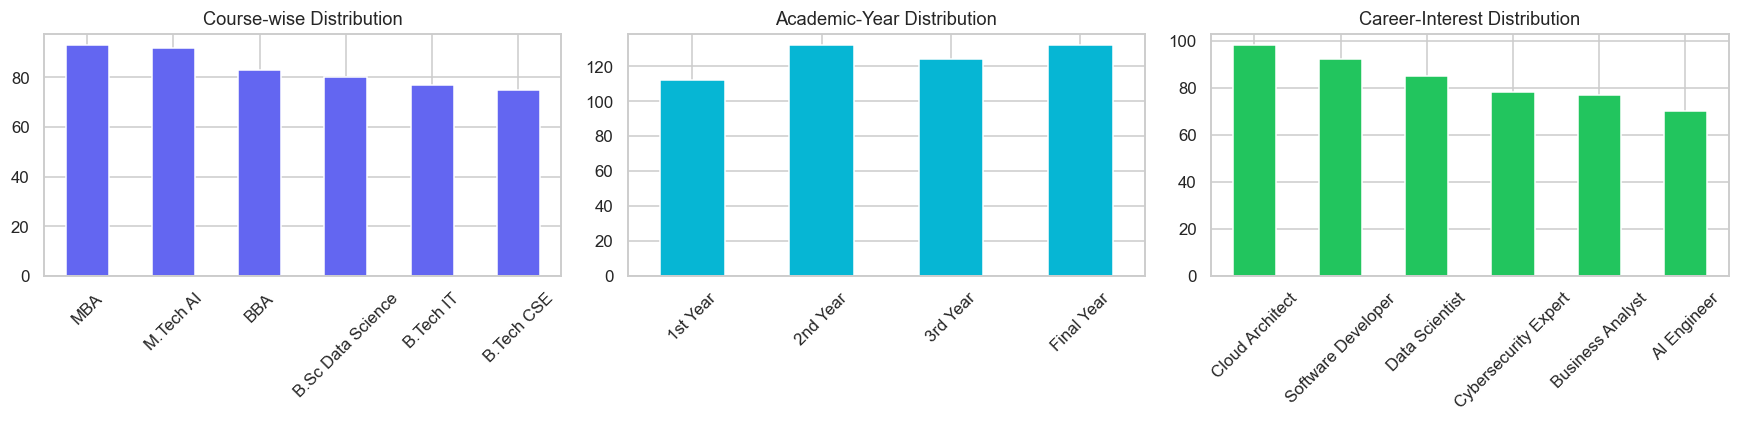

In [5]:
frame = eda.build_analysis_frame()
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
eda.course_distribution(frame).plot(kind="bar", ax=ax[0], color="#6366f1", title="Course-wise Distribution")
eda.year_distribution(frame).plot(kind="bar", ax=ax[1], color="#06b6d4", title="Academic-Year Distribution")
eda.career_interest_distribution(frame).plot(kind="bar", ax=ax[2], color="#22c55e", title="Career-Interest Distribution")
for a in ax: a.set_xlabel(""); a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 4. Skill analysis — technical skills, languages & soft skills

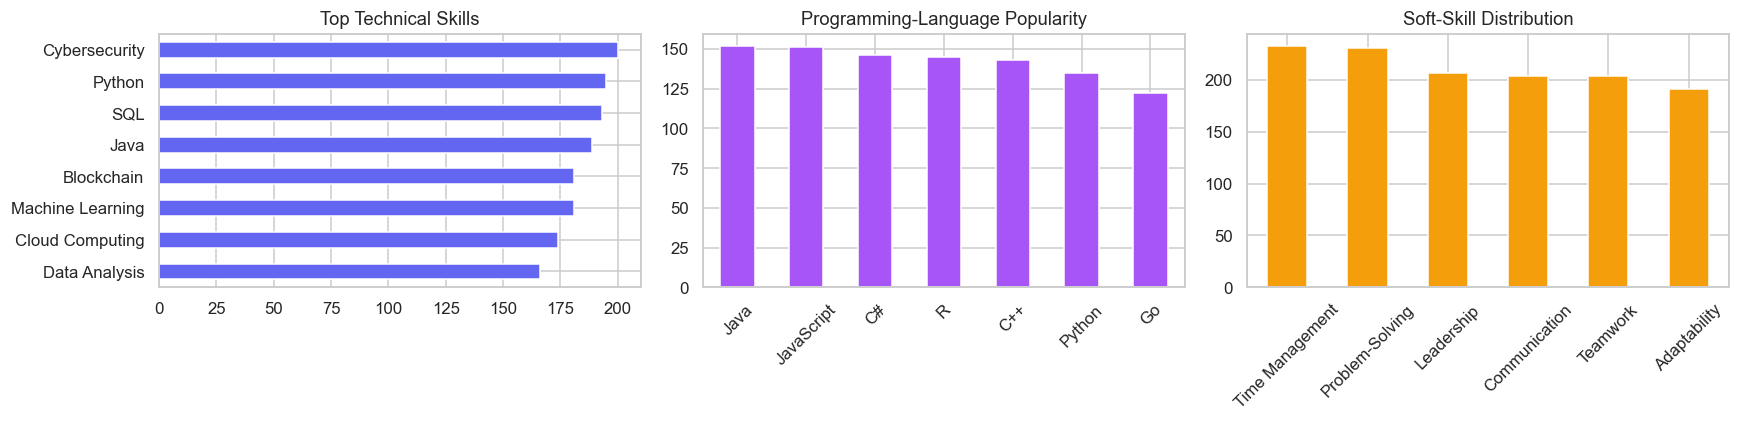

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
eda.top_technical_skills(frame).sort_values().plot(kind="barh", ax=ax[0], color="#6366f1", title="Top Technical Skills")
eda.language_popularity(frame).plot(kind="bar", ax=ax[1], color="#a855f7", title="Programming-Language Popularity")
eda.soft_skill_distribution(frame).plot(kind="bar", ax=ax[2], color="#f59e0b", title="Soft-Skill Distribution")
ax[1].tick_params(axis="x", rotation=45); ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 5. Career-readiness analysis
The custom 0–100 readiness score and its band distribution.

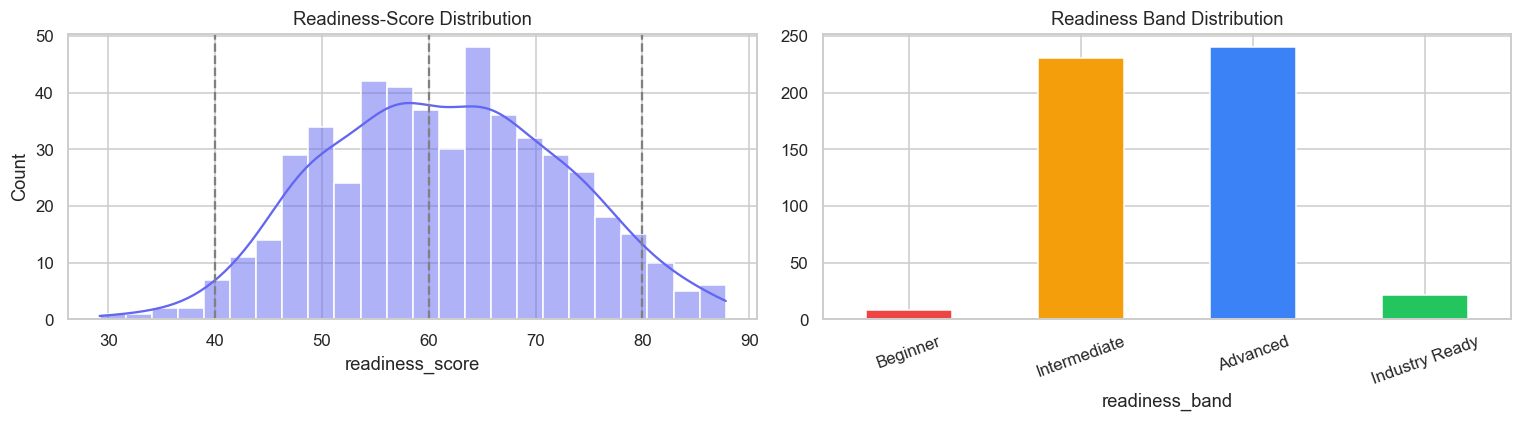

          pillar  avg_points  max_points  gap  attainment_pct
Technical Skills        26.6        40.0 13.4            66.5
     Programming        13.3        20.0  6.7            66.3
     Soft Skills        12.3        20.0  7.7            61.3
        Projects         5.7        10.0  4.3            56.8
Career Alignment         3.7        10.0  6.3            36.8


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(frame["readiness_score"], bins=24, kde=True, color="#6366f1", ax=ax[0])
for b in (40, 60, 80): ax[0].axvline(b, ls="--", c="grey")
ax[0].set_title("Readiness-Score Distribution")
eda.readiness_band_distribution(frame).plot(kind="bar", ax=ax[1],
    color=["#ef4444","#f59e0b","#3b82f6","#22c55e"], title="Readiness Band Distribution")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print(eda.skill_gap_summary(frame).to_string(index=False))

## 6. Correlation analysis

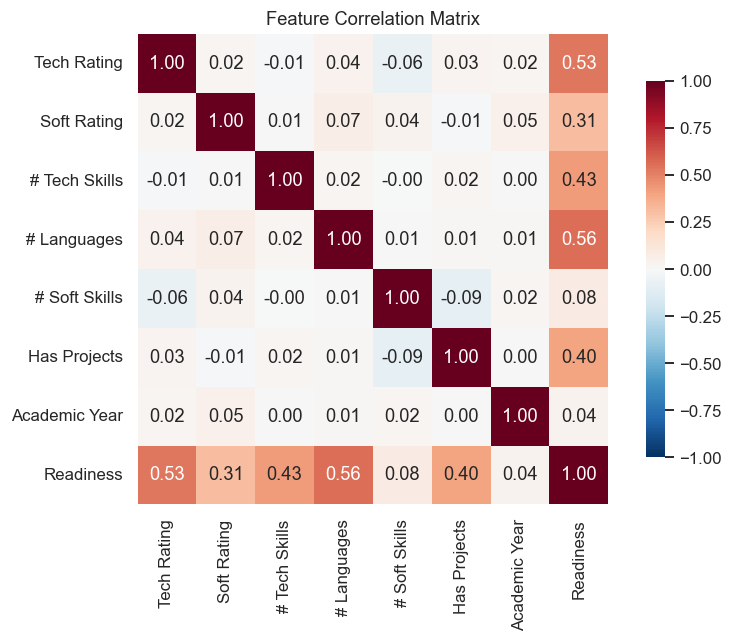

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(eda.correlation_matrix(frame), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
plt.title("Feature Correlation Matrix"); plt.tight_layout(); plt.show()

## 7. Target engineering
The ML target `recommended_career` is produced by an expert decision rubric
(interest → family → refined by course/skills) plus light label noise.

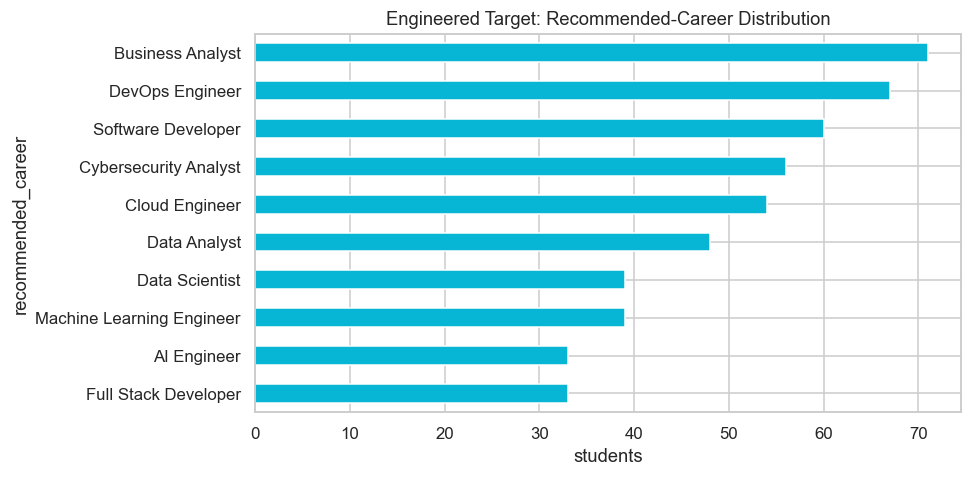

In [9]:
ax = eda.recommended_career_distribution(frame).sort_values().plot(
    kind="barh", figsize=(9, 4.5), color="#06b6d4",
    title="Engineered Target: Recommended-Career Distribution")
ax.set_xlabel("students"); plt.tight_layout(); plt.show()

## 8. Preprocessing & featurisation

In [10]:
from src.preprocessing import run_preprocessing, featurize, detect_outliers
proc = run_preprocessing(load_clean())
X = featurize(proc)
print("Feature matrix:", X.shape)
print("Sample feature columns:", list(X.columns[:10]), "...")
print("\nOutlier scan (IQR):")
for k, v in detect_outliers(proc).items():
    print(f"  {k:<20} outliers={v['n_outliers']} ({v['pct_outliers']}%)")

Feature matrix: (500, 54)
Sample feature columns: ['technical_rating', 'soft_rating', 'n_technical_skills', 'n_languages', 'n_soft_skills', 'readiness_score', 'year_ordinal', 'has_projects_bin', 'course__B.Tech CSE', 'course__B.Tech IT'] ...

Outlier scan (IQR):
  technical_rating     outliers=0 (0.0%)
  soft_rating          outliers=0 (0.0%)
  n_technical_skills   outliers=0 (0.0%)
  n_languages          outliers=0 (0.0%)
  n_soft_skills        outliers=0 (0.0%)
  readiness_score      outliers=1 (0.2%)


## 9. Model comparison & evaluation
Loaded from `models/model_metrics.json` (produced by `python train.py`).
Five classifiers are compared; the best is auto-selected by 5-fold CV F1.

In [11]:
import json, os
with open(config.METRICS_PATH) as fh: metrics = json.load(fh)
rows = [{"Model": n, "Accuracy": round(m["accuracy"],3), "Precision": round(m["precision"],3),
         "Recall": round(m["recall"],3), "F1": round(m["f1"],3), "CV-F1": round(m["cv_f1_mean"],3)}
        for n, m in metrics["models"].items()]
comp = pd.DataFrame(rows).sort_values("CV-F1", ascending=False).reset_index(drop=True)
print("Best model (auto-selected):", metrics["best_model"])
comp

Best model (auto-selected): Random Forest


,Model,Accuracy,Precision,Recall,F1,CV-F1
0,Random Forest,0.94,0.950,0.94,0.941,0.909
1,Decision Tree,0.94,0.950,0.94,0.941,0.897
2,Gradient Boosting,0.92,0.928,0.92,0.919,0.889
3,XGBoost,0.90,0.908,0.90,0.899,0.881
4,Logistic Regression,0.74,0.745,0.74,0.735,0.750


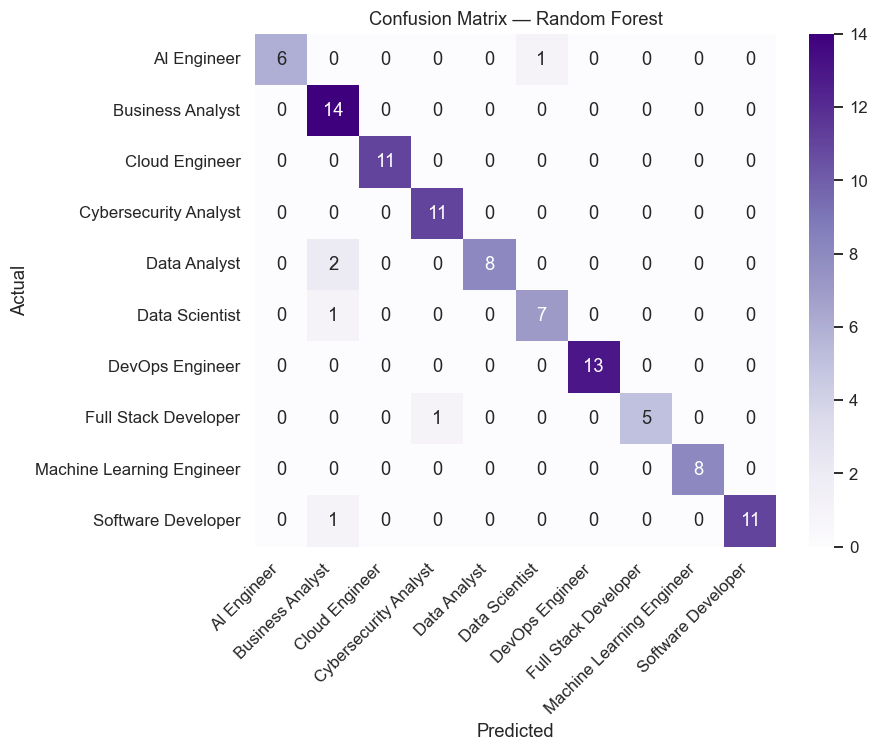

In [12]:
best = metrics["models"][metrics["best_model"]]
cm = np.array(best["confusion_matrix"]); classes = metrics["classes"]
plt.figure(figsize=(8.5, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix — {metrics['best_model']}")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

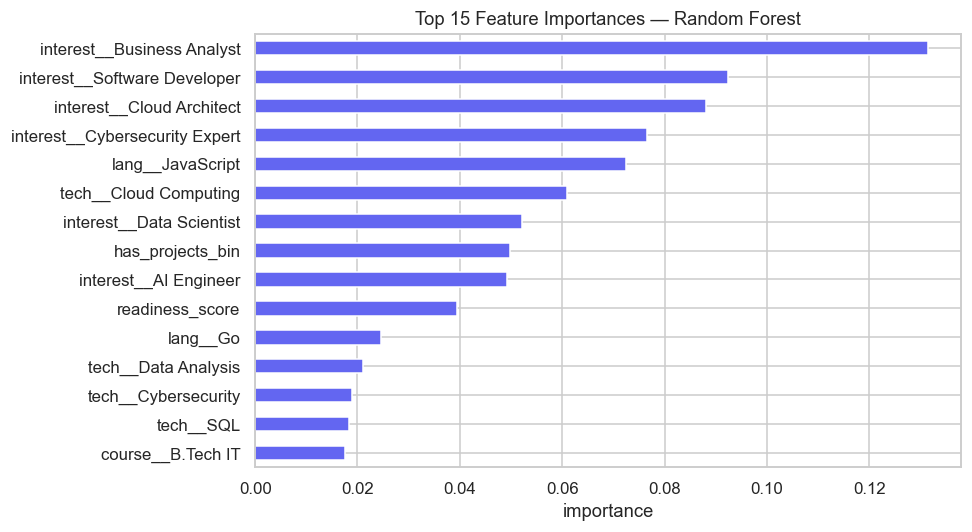

In [13]:
imp = metrics["feature_importance"]; top = dict(list(imp.items())[:15])
plt.figure(figsize=(9, 5))
pd.Series(top).sort_values().plot(kind="barh", color="#6366f1")
plt.title(f"Top 15 Feature Importances — {metrics['best_model']}")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

## 10. Conclusion
- The pipeline cleans 500 student records, engineers **54 features** and a transparent
  expert-rubric **target**.
- Five models are compared; **Random Forest** is auto-selected with **~94% accuracy**
  and **0.94 macro-F1**.
- Feature importances mirror the decision rubric (career interest, JavaScript, Cloud
  Computing, projects), confirming the model learned the intended logic.
- The trained artefacts power the **SkillPath AI** Streamlit app for live career
  prediction, readiness scoring, skill-gap detection and growth-pathway generation.